I am having some issues with my code, and I need to compare 5 different things to sort it out:
1. Sample $a_{max}/ f$ by accident, feed DSHARP $a_{max}/f$ (incorrect but old way)
2. Sample $a_{max}/ f$ by accident, feed DSHARP $a_{max}$
3. Sample $a_{max}*f$, feed DSHARP $a_{max} * f$ (incorrect), 
4. Sample $a_{max}*f$, feed DSHARP $a_{max}$, plot $a_{max}$
5. Sample $a_{max}$, feed DSHARP $a_{max}$ (correct), plot $a_{max}$ (new way)

For a proper comparison, I will be using the same $a_{max}$ grid and number of particles.

I want to see how $\chi^2$ changes

I will also only just consider the without Band 5 fit

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packa

In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
all_bands    = ["Band 4 nterms2",  "Band 5", "Band 5 robust -1",     "Band 6", "Band 7 nterms2"]
bands_naming = ['Band4_nterms2',   'Band5',  "Band5_robust_minus1",  'Band6',  'Band7_nterms2']
bands_labels = ['Band 4',          'Band 5', "Band 5 robust -1",      'Band 6', 'Band 7']
bands_fit = ["Band 4 nterms2",  "Band 5 robust -1", "Band 6", "Band 7 nterms2"]

lambda_bands_cm = mm_to_cm([lambda_mm[b] for b in all_bands])

In [4]:
df_POLF = load_POLF(all_bands, print_things = True)

POLF_type = 'max Stokes I'

POLF_obs_for_plot = dict(zip(df_POLF["Band"], df_POLF["POLF_maxStokesI"]))

Band = Band 4 nterms2
Band = Band 5
Band = Band 5 robust -1
Band = Band 6
Band = Band 7 nterms2
 in load_POLF, results = {'Band': ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2'], 'POLF_Gaussian': [1.1877280000000001, 0.9329613999999999, 1.3769860999999999, 1.4453122, 0.8302132], 'POLF_maxPOLI': [1.561384, 1.0520775, 1.5137895000000001, 1.4862873, 1.0841521], 'POLF_maxStokesI': [1.3677061000000001, 0.9908963, 1.4034492, 1.4639224, 1.0421403]}


In [5]:
f_values = [1, 0.75, 0.5, 0.25]

In [6]:
# This is stuff for the sf calculations 

polf_columns = {
    'gaussian': 'POLF_Gaussian',
    'max Stokes I': 'POLF_maxStokesI',
    'POLI': 'POLF_maxPOLI',
    'mean': 'POLF_mean'
}

POLF_index = POLF_type

if POLF_index not in polf_columns:
    raise ValueError(
        "POLF_index must be 'gaussian', 'poli', 'avg', 'mean', or 'max Stokes I'"
    )
    
bands_included_in_fit = ["Band 4 nterms2",  "Band 5 robust -1", "Band 6", "Band 7 nterms2"]
    
# Band names → indices (0, 1, 2, etc)
band_to_index = {band: i for i, band in enumerate(all_bands)}
fit_indices = [band_to_index[b] for b in bands_included_in_fit]

POLF_obs_all = df_POLF[polf_columns[POLF_index]].values

In [7]:
base_path = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/DUST MODEL NOTEBOOKS/P_omega_Data/"

path_v1 = base_path + 'Debugging_v1/'
path_v2 = base_path + 'Debugging_v2/'
path_v3 = base_path + 'Debugging_v3/'
path_v4 = base_path + 'Debugging_v4/'
path_v5 = base_path + 'Debugging_v5/'

In [8]:
minn = {
    1: 50 / 1,
    0.75: 50 / 1,
    0.5: 30 / 0.5,
    0.25: 5 / 0.25,
}

maxx = {
    1: 501 / 1,
    0.75: 501 / 0.75,
    0.5: 1000 / 0.5,
    0.25: 1000 / 0.25,
}

N = {
    1: (501 - 50) + 1,
    0.75: (501 - 50) + 1,
    0.5: 500,
    0.25: 500,
}

# v1: Sample $a_{max} / f$, feed DSHARP $a_{max} / f$ 

In [9]:
# MakeCurves('v1', f_values, minn, maxx, N, lambda_bands_cm, bands_naming)

In [10]:
csv_files_v1 = {
    1:    "data_debugging_v1_1.csv",
    0.75: "data_debugging_v1_0_75.csv",
    0.5:  "data_debugging_v1_0_5.csv",
    0.25: "data_debugging_v1_0_25.csv",
}

In [11]:
# Make some empty arrays for stuff

a_divided_by_f_dist_micron_v1 = {}
P_times_omega_v1 = {}
best_a_max_divided_f_v1 = {}
POLF_obs_v1 = {}
best_sf_v1 = {}
best_idx_arr_v1 = {}
P_times_omega_v1 = {}


# Loop over f values and csv files
for f, fname in csv_files_v1.items():

    df = pd.read_csv(path_v1  + fname)

    # x-axis
    a_max_divided_by_f_vals = df["Xdata"].values
    a_divided_by_f_dist_micron_v1[f] = a_max_divided_by_f_vals

    # ALL bands
    Pw = np.column_stack([
        df[f"P_times_omega_{b}"].values for b in bands_naming
    ])
    P_times_omega_v1[f] = Pw


    sf_medians, best_idx = STDEV_Calculations(a_max_divided_by_f_vals, Pw, fit_indices, POLF_obs_all)




    best_a_max_divided_f_v1[f] = a_max_divided_by_f_vals[best_idx]
    best_sf_v1[f] = sf_medians[best_idx]
    best_idx_arr_v1[f] = best_idx
    POLF_obs_v1[f] = np.array([
    POLF_obs_all[band_to_index[b]] for b in all_bands
])

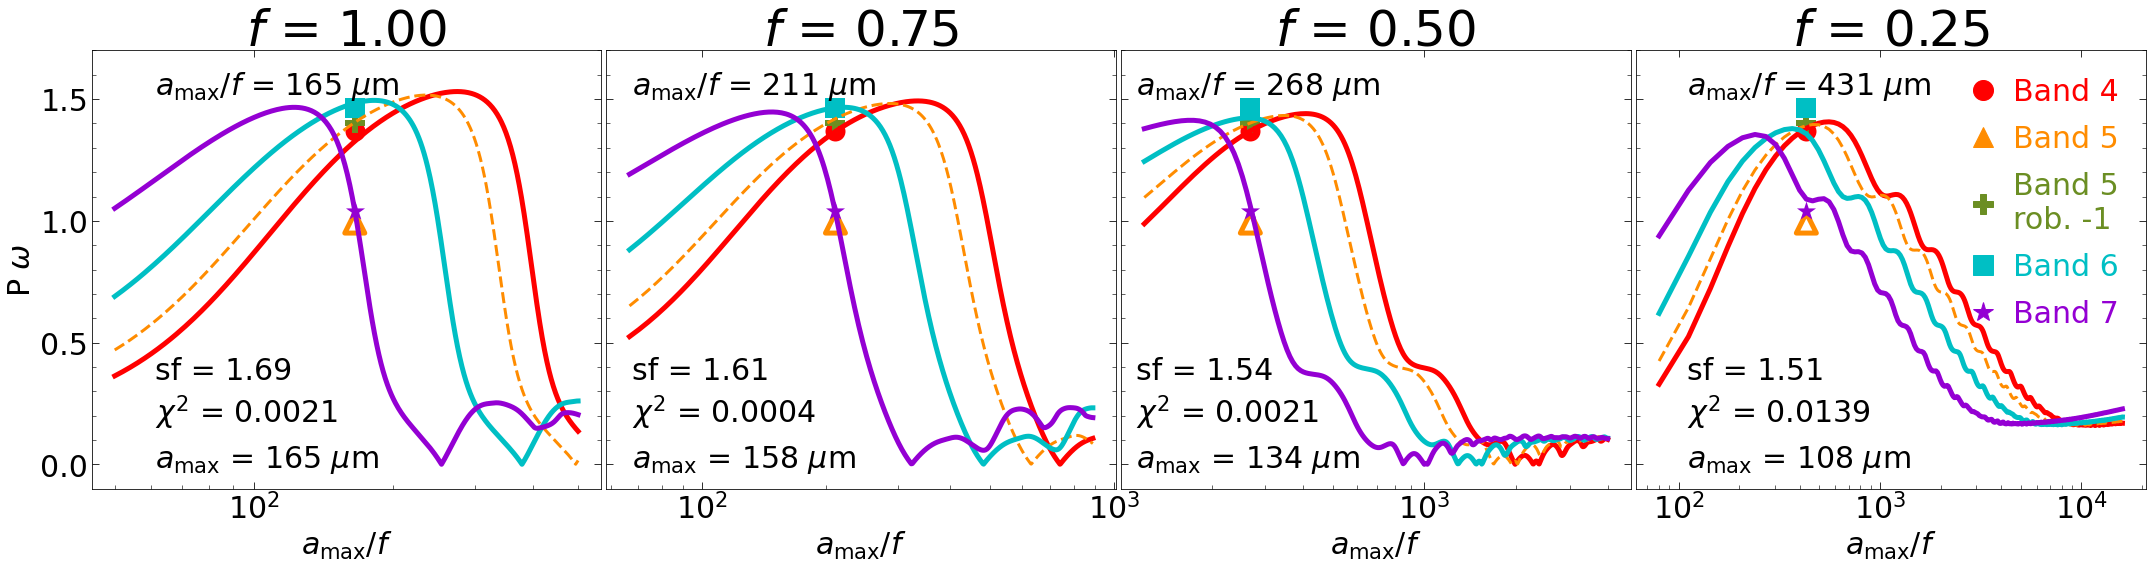

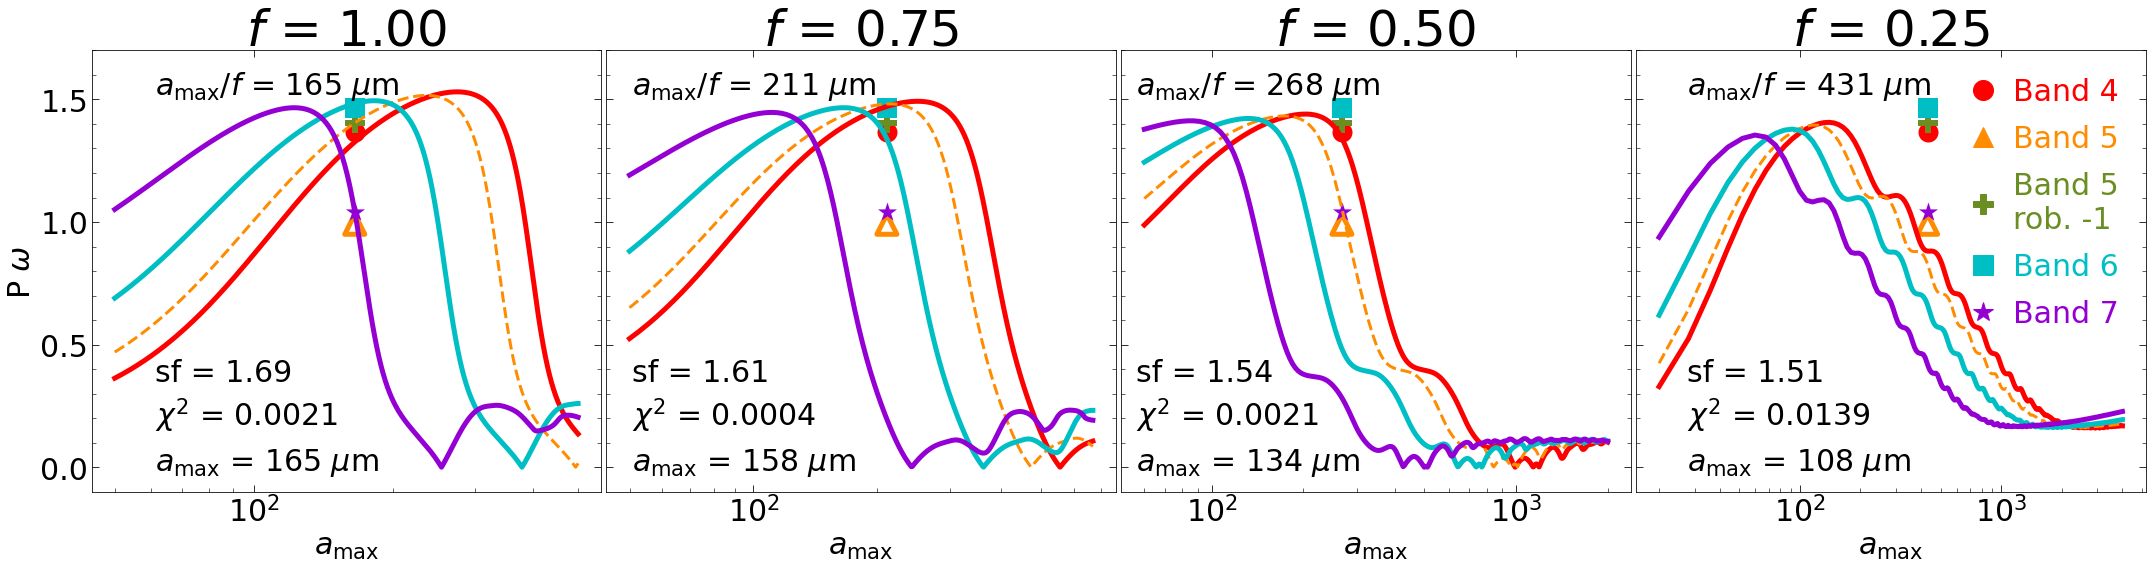

In [12]:
fig, ax = DebuggingPlot('v1',
                        all_bands, 
                        bands_labels, 
                        bands_fit, 
                        f_values,                               
                        a_divided_by_f_dist_micron_v1, 
                        P_times_omega_v1,
                        best_sf_v1, 
                        best_idx_arr_v1, 
                        best_a_max_divided_f_v1, 
                        POLF_obs_for_plot,
                        x_axis = 'a/f',
                        custom_text_x = [0.075, 0, -0.02, 0.05],
                        chi_sq_precision = 4,
                        )


fig, ax = DebuggingPlot('v1',
                        all_bands, 
                        bands_labels, 
                        bands_fit, 
                        f_values,                               
                        a_divided_by_f_dist_micron_v1, 
                        P_times_omega_v1,
                        best_sf_v1, 
                        best_idx_arr_v1, 
                        best_a_max_divided_f_v1, 
                        POLF_obs_for_plot,
                        x_axis = 'a',
                        custom_text_x = [0.075, 0, -0.02, 0.05],
                        chi_sq_precision = 4,
                        )

# v2: Sample $a_{max} / f$, feed DSHARP $a_{max}$ 

In [13]:
# MakeCurves('v2', f_values, minn, maxx, N, lambda_bands_cm, bands_naming)

In [14]:
csv_files_v2 = {
    1:    "data_debugging_v2_1.csv",
    0.75: "data_debugging_v2_0_75.csv",
    0.5:  "data_debugging_v2_0_5.csv",
    0.25: "data_debugging_v2_0_25.csv",
}

In [15]:
# Make some empty arrays for stuff

a_divided_by_f_dist_micron_v2 = {}
P_times_omega_v2 = {}
best_a_max_divided_f_v2 = {}
POLF_obs_v2 = {}
best_sf_v2 = {}
best_idx_arr_v2 = {}
P_times_omega_v2 = {}


# Loop over f values and csv files
for f, fname in csv_files_v2.items():

    df = pd.read_csv(path_v2  + fname)

    # x-axis
    a_max_divided_by_f_vals = df["Xdata"].values
    a_divided_by_f_dist_micron_v2[f] = a_max_divided_by_f_vals

    # ALL bands
    Pw = np.column_stack([
        df[f"P_times_omega_{b}"].values for b in bands_naming
    ])
    P_times_omega_v2[f] = Pw


    sf_medians, best_idx = STDEV_Calculations(a_max_divided_by_f_vals, Pw, fit_indices, POLF_obs_all)




    best_a_max_divided_f_v2[f] = a_max_divided_by_f_vals[best_idx]
    best_sf_v2[f] = sf_medians[best_idx]
    best_idx_arr_v2[f] = best_idx
    POLF_obs_v2[f] = np.array([
    POLF_obs_all[band_to_index[b]] for b in all_bands
])

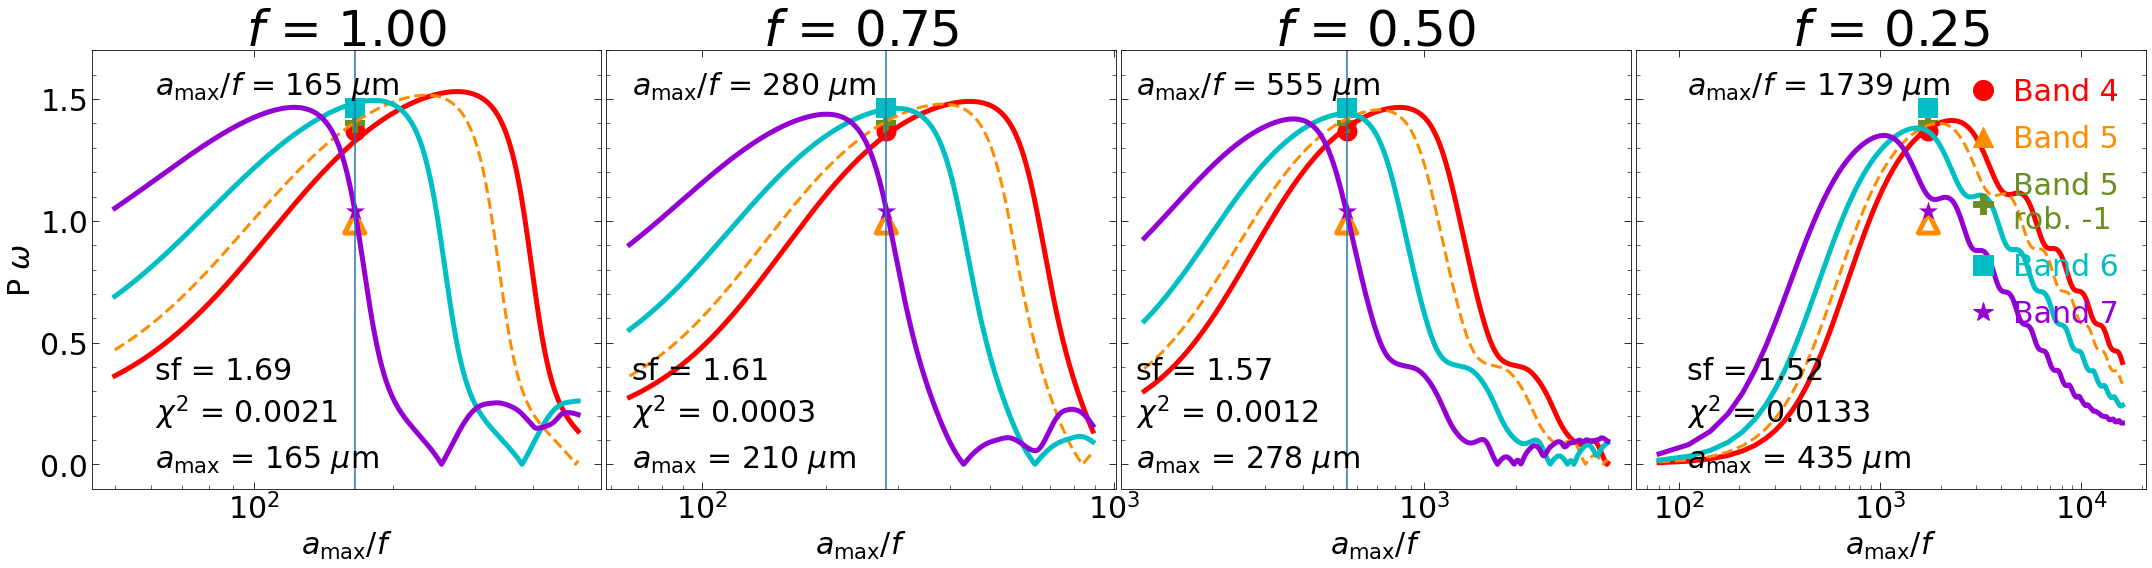

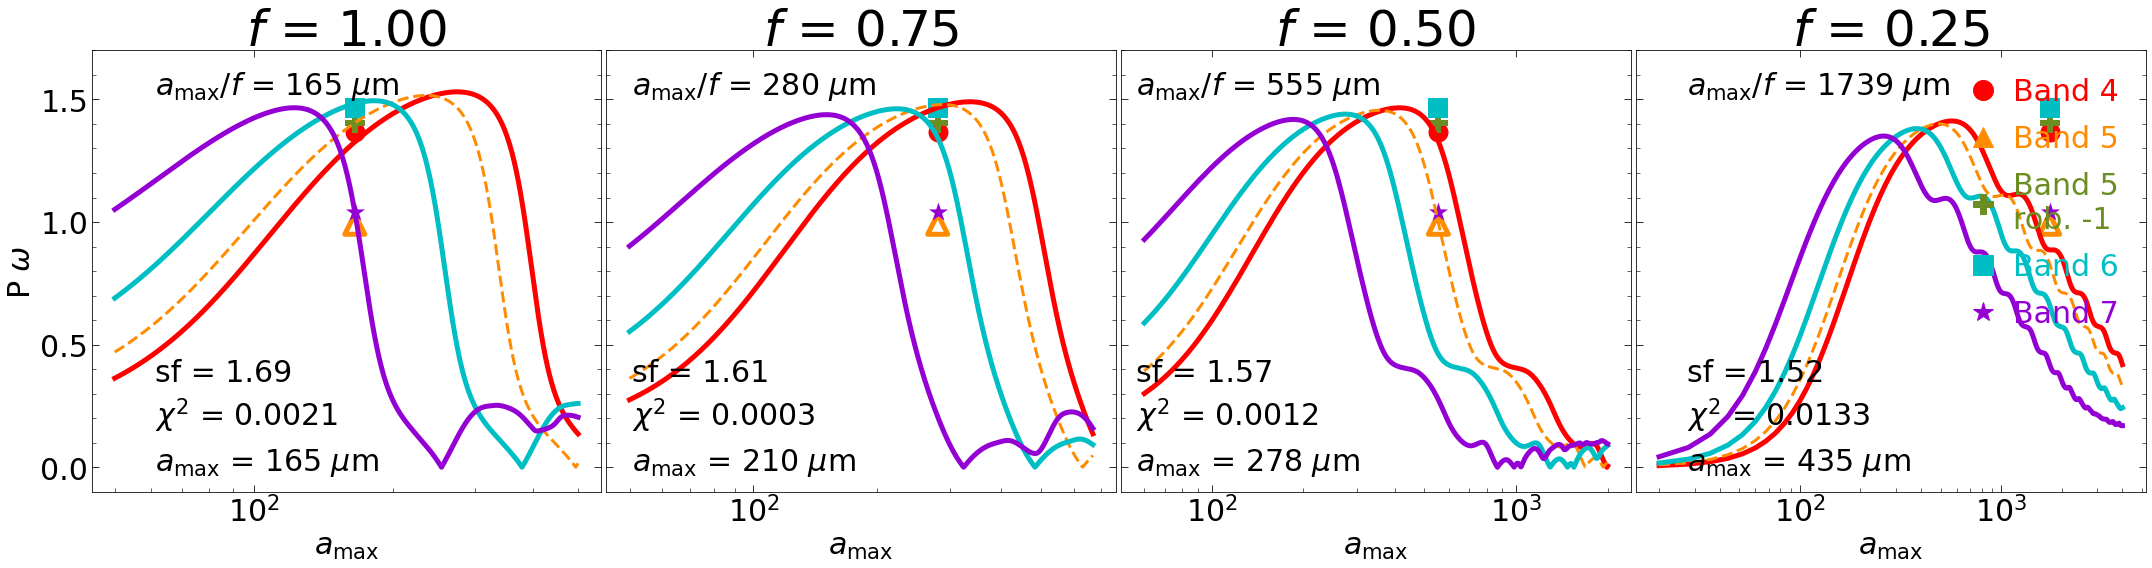

In [16]:
fig, ax = DebuggingPlot('v2',
                        all_bands, 
                        bands_labels, 
                        bands_fit, 
                        f_values,                               
                        a_divided_by_f_dist_micron_v2, 
                        P_times_omega_v2,
                        best_sf_v2, 
                        best_idx_arr_v2, 
                        best_a_max_divided_f_v2, 
                        POLF_obs_for_plot,
                        x_axis = 'a/f',
                        custom_text_x = [0.075, 0, -0.02, 0.05],
                        chi_sq_precision = 4,
                        )

ax[0].axvline(165)
ax[1].axvline(280)
ax[2].axvline(555)


fig, ax = DebuggingPlot('v2',
                        all_bands, 
                        bands_labels, 
                        bands_fit, 
                        f_values,                               
                        a_divided_by_f_dist_micron_v2, 
                        P_times_omega_v2,
                        best_sf_v2, 
                        best_idx_arr_v2, 
                        best_a_max_divided_f_v2, 
                        POLF_obs_for_plot,
                        x_axis = 'a',
                        custom_text_x = [0.075, 0, -0.02, 0.05],
                        chi_sq_precision = 4,
                        )

# v3: Sample $a_{max} * f$, feed DSHARP $a_{max}*f$ 

In [17]:
# MakeCurves('v3', f_values, minn, maxx, N, lambda_bands_cm, bands_naming)

In [18]:
csv_files_v3 = {
    1:    "data_debugging_v3_1.csv",
    0.75: "data_debugging_v3_0_75.csv",
    0.5:  "data_debugging_v3_0_5.csv",
    0.25: "data_debugging_v3_0_25.csv",
}

In [19]:
# Make some empty arrays for stuff

a_multiplied_by_f_dist_micron_v3 = {}
P_times_omega_v3 = {}
best_a_max_multiplied_f_v3 = {}
POLF_obs_v3 = {}
best_sf_v3 = {}
best_idx_arr_v3 = {}
P_times_omega_v3 = {}


# Loop over f values and csv files
for f, fname in csv_files_v3.items():

    df = pd.read_csv(path_v3  + fname)

    # x-axis
    a_max_multiplied_by_f_vals = df["Xdata"].values
    a_multiplied_by_f_dist_micron_v3[f] = a_max_multiplied_by_f_vals

    # ALL bands
    Pw = np.column_stack([
        df[f"P_times_omega_{b}"].values for b in bands_naming
    ])
    P_times_omega_v3[f] = Pw


    sf_medians, best_idx = STDEV_Calculations(a_max_multiplied_by_f_vals, Pw, fit_indices, POLF_obs_all)




    best_a_max_multiplied_f_v3[f] = a_max_multiplied_by_f_vals[best_idx]
    best_sf_v3[f] = sf_medians[best_idx]
    best_idx_arr_v3[f] = best_idx
    POLF_obs_v3[f] = np.array([
    POLF_obs_all[band_to_index[b]] for b in all_bands
])

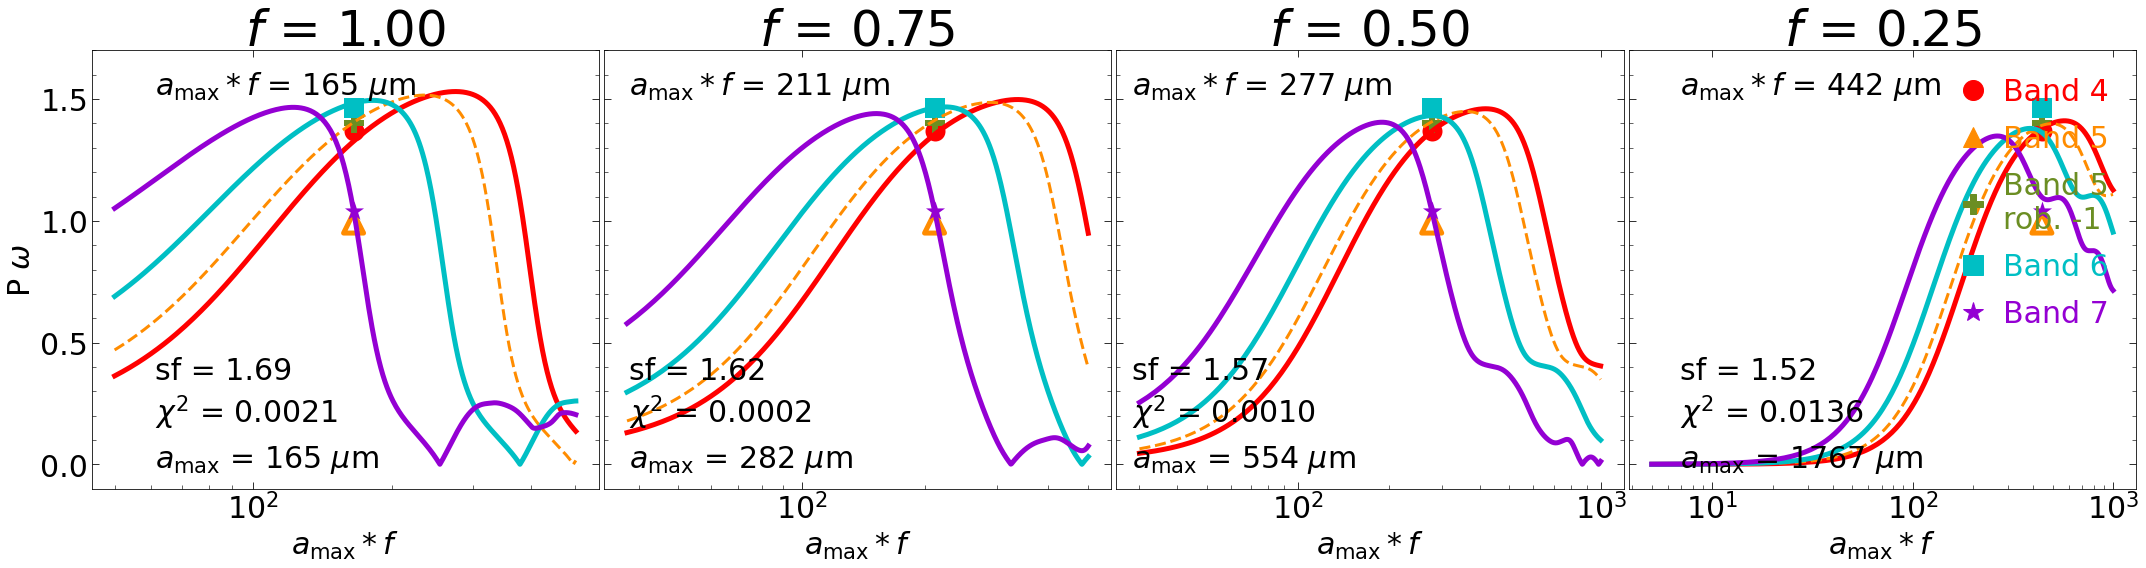

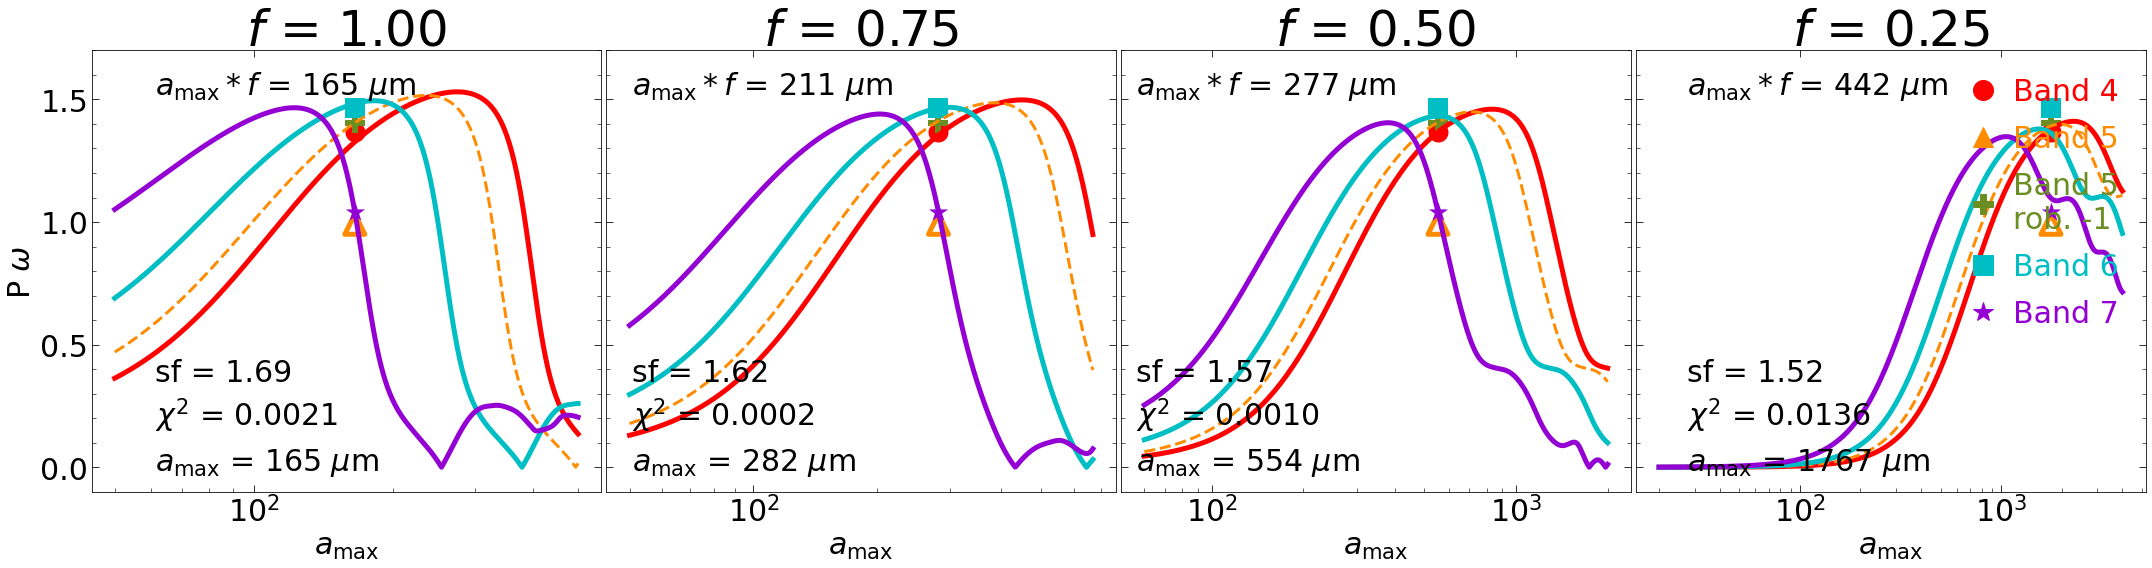

In [20]:
fig, ax = DebuggingPlot('v3',
                        all_bands, 
                        bands_labels, 
                        bands_fit, 
                        f_values,                               
                        a_multiplied_by_f_dist_micron_v3, 
                        P_times_omega_v3,
                        best_sf_v3, 
                        best_idx_arr_v3, 
                        best_a_max_multiplied_f_v3, 
                        POLF_obs_for_plot,
                        x_axis = 'a*f',
                        custom_text_x = [0.075, 0, -0.02, 0.05],
                        chi_sq_precision = 4,
                        )


fig, ax = DebuggingPlot('v3',
                        all_bands, 
                        bands_labels, 
                        bands_fit, 
                        f_values,                               
                        a_multiplied_by_f_dist_micron_v3, 
                        P_times_omega_v3,
                        best_sf_v3, 
                        best_idx_arr_v3, 
                        best_a_max_multiplied_f_v3, 
                        POLF_obs_for_plot,
                        x_axis = 'a',
                        custom_text_x = [0.075, 0, -0.02, 0.05],
                        chi_sq_precision = 4,
                        )

# v4: Sample $a_{max} * f$, feed DSHARP $a_{max}$ 

In [21]:
# MakeCurves('v4', f_values, minn, maxx, N, lambda_bands_cm, bands_naming)

In [22]:
csv_files_v4 = {
    1:    "data_debugging_v4_1.csv",
    0.75: "data_debugging_v4_0_75.csv",
    0.5:  "data_debugging_v4_0_5.csv",
    0.25: "data_debugging_v4_0_25.csv",
}

In [23]:
# Make some empty arrays for stuff

a_multiplied_by_f_dist_micron_v4 = {}
P_times_omega_v4 = {}
best_a_max_multiplied_f_v4 = {}
POLF_obs_v4 = {}
best_sf_v4 = {}
best_idx_arr_v4 = {}
P_times_omega_v4 = {}


# Loop over f values and csv files
for f, fname in csv_files_v4.items():

    df = pd.read_csv(path_v4  + fname)

    # x-axis
    a_max_multiplied_by_f_vals = df["Xdata"].values
    a_multiplied_by_f_dist_micron_v4[f] = a_max_multiplied_by_f_vals

    # ALL bands
    Pw = np.column_stack([
        df[f"P_times_omega_{b}"].values for b in bands_naming
    ])
    P_times_omega_v4[f] = Pw


    sf_medians, best_idx = STDEV_Calculations(a_max_multiplied_by_f_vals, Pw, fit_indices, POLF_obs_all)




    best_a_max_multiplied_f_v4[f] = a_max_multiplied_by_f_vals[best_idx]
    best_sf_v4[f] = sf_medians[best_idx]
    best_idx_arr_v4[f] = best_idx
    POLF_obs_v4[f] = np.array([
    POLF_obs_all[band_to_index[b]] for b in all_bands
])

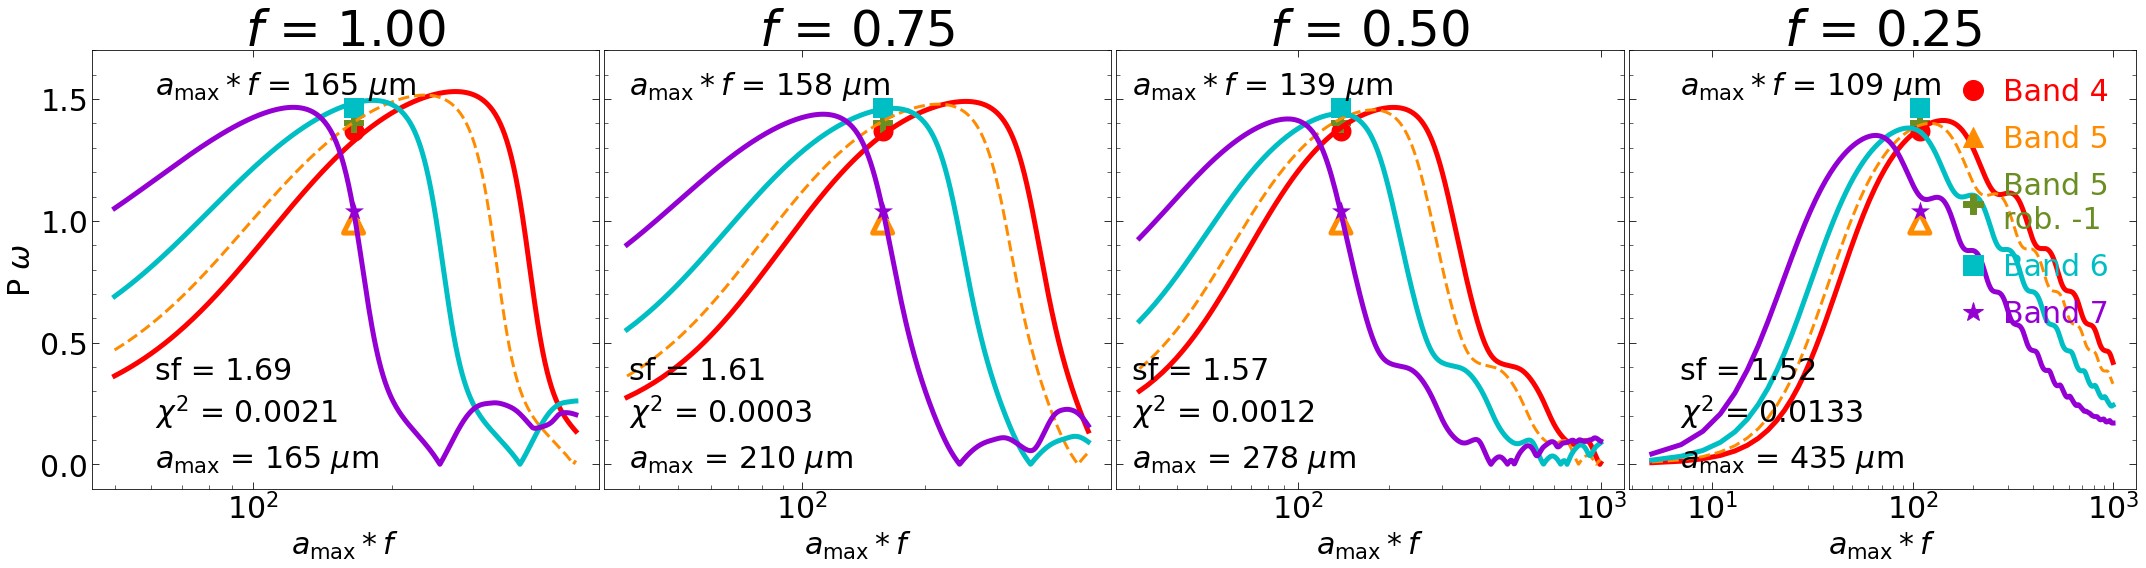

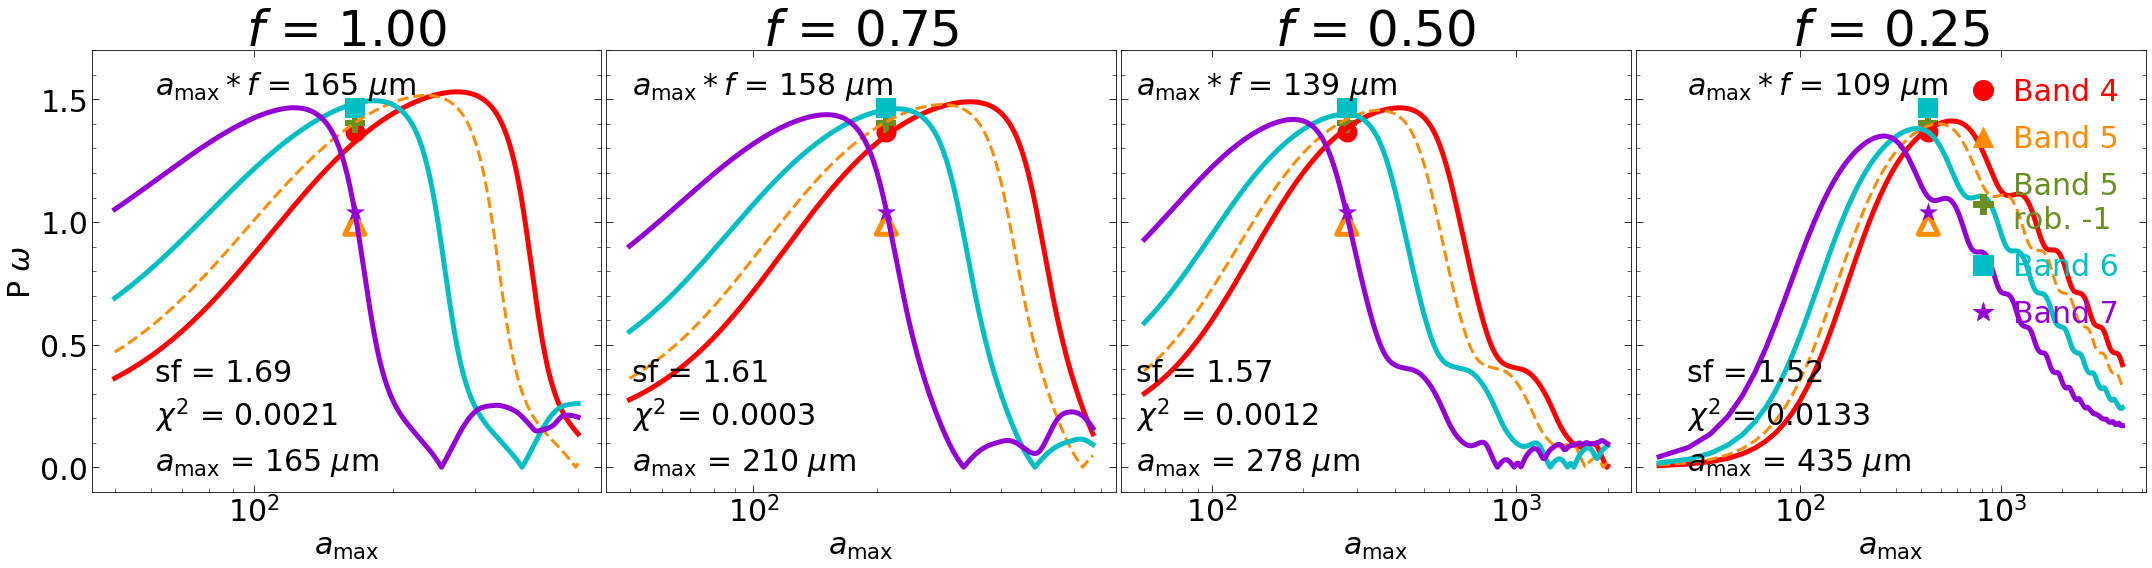

In [24]:
fig, ax = DebuggingPlot('v4',
                        all_bands, 
                        bands_labels, 
                        bands_fit, 
                        f_values,                               
                        a_multiplied_by_f_dist_micron_v4, 
                        P_times_omega_v4,
                        best_sf_v4, 
                        best_idx_arr_v4, 
                        best_a_max_multiplied_f_v4, 
                        POLF_obs_for_plot,
                        x_axis = 'a*f',
                        custom_text_x = [0.075, 0, -0.02, 0.05],
                        chi_sq_precision = 4,
                        )


fig, ax = DebuggingPlot('v4',
                        all_bands, 
                        bands_labels, 
                        bands_fit, 
                        f_values,                               
                        a_multiplied_by_f_dist_micron_v4, 
                        P_times_omega_v4,
                        best_sf_v4, 
                        best_idx_arr_v4, 
                        best_a_max_multiplied_f_v4, 
                        POLF_obs_for_plot,
                        x_axis = 'a',
                        custom_text_x = [0.075, 0, -0.02, 0.05],
                        chi_sq_precision = 4,
                        )

## What is the difference between the curves for v3 and v4?

In [25]:
# Loop over all f values
for f in f_values:
    
    all_diff_x = np.abs(a_multiplied_by_f_dist_micron_v4[f]  - a_multiplied_by_f_dist_micron_v3[f])
    all_diff_y = np.abs(P_times_omega_v4[f]  - P_times_omega_v3[f])
    
    sum_x = np.sum(all_diff_x)
    sum_y = np.sum(all_diff_y)
    
    print(rf"f = {f}, sum xaxis = {sum_x}, sum yaxis = {sum_y}")
    

f = 1, sum xaxis = 0.0, sum yaxis = 0.0
f = 0.75, sum xaxis = 0.0, sum yaxis = 493.0820346739466
f = 0.5, sum xaxis = 0.0, sum yaxis = 785.7637862454114
f = 0.25, sum xaxis = 0.0, sum yaxis = 1025.7078542285976


# v5: Sample $a_{max} , feed DSHARP $a_{max}$ 

In [26]:
# MakeCurves('v5', f_values, minn, maxx, N, lambda_bands_cm, bands_naming)

In [27]:
csv_files_v5 = {
    1:    "data_debugging_v5_1.csv",
    0.75: "data_debugging_v5_0_75.csv",
    0.5:  "data_debugging_v5_0_5.csv",
    0.25: "data_debugging_v5_0_25.csv",
}

In [28]:
# Make some empty arrays for stuff

a_dist_micron_v5 = {}
P_times_omega_v5 = {}
best_a_max_v5 = {}
POLF_obs_v5 = {}
best_sf_v5 = {}
best_idx_arr_v5 = {}
P_times_omega_v5 = {}


# Loop over f values and csv files
for f, fname in csv_files_v5.items():

    df = pd.read_csv(path_v5  + fname)

    # x-axis
    a_max_vals = df["Xdata"].values
    a_dist_micron_v5[f] = a_max_vals

    # ALL bands
    Pw = np.column_stack([
        df[f"P_times_omega_{b}"].values for b in bands_naming
    ])
    P_times_omega_v5[f] = Pw


    sf_medians, best_idx = STDEV_Calculations(a_max_vals, Pw, fit_indices, POLF_obs_all)




    best_a_max_v5[f] = a_max_vals[best_idx]
    best_sf_v5[f] = sf_medians[best_idx]
    best_idx_arr_v5[f] = best_idx
    POLF_obs_v5[f] = np.array([
    POLF_obs_all[band_to_index[b]] for b in all_bands
])

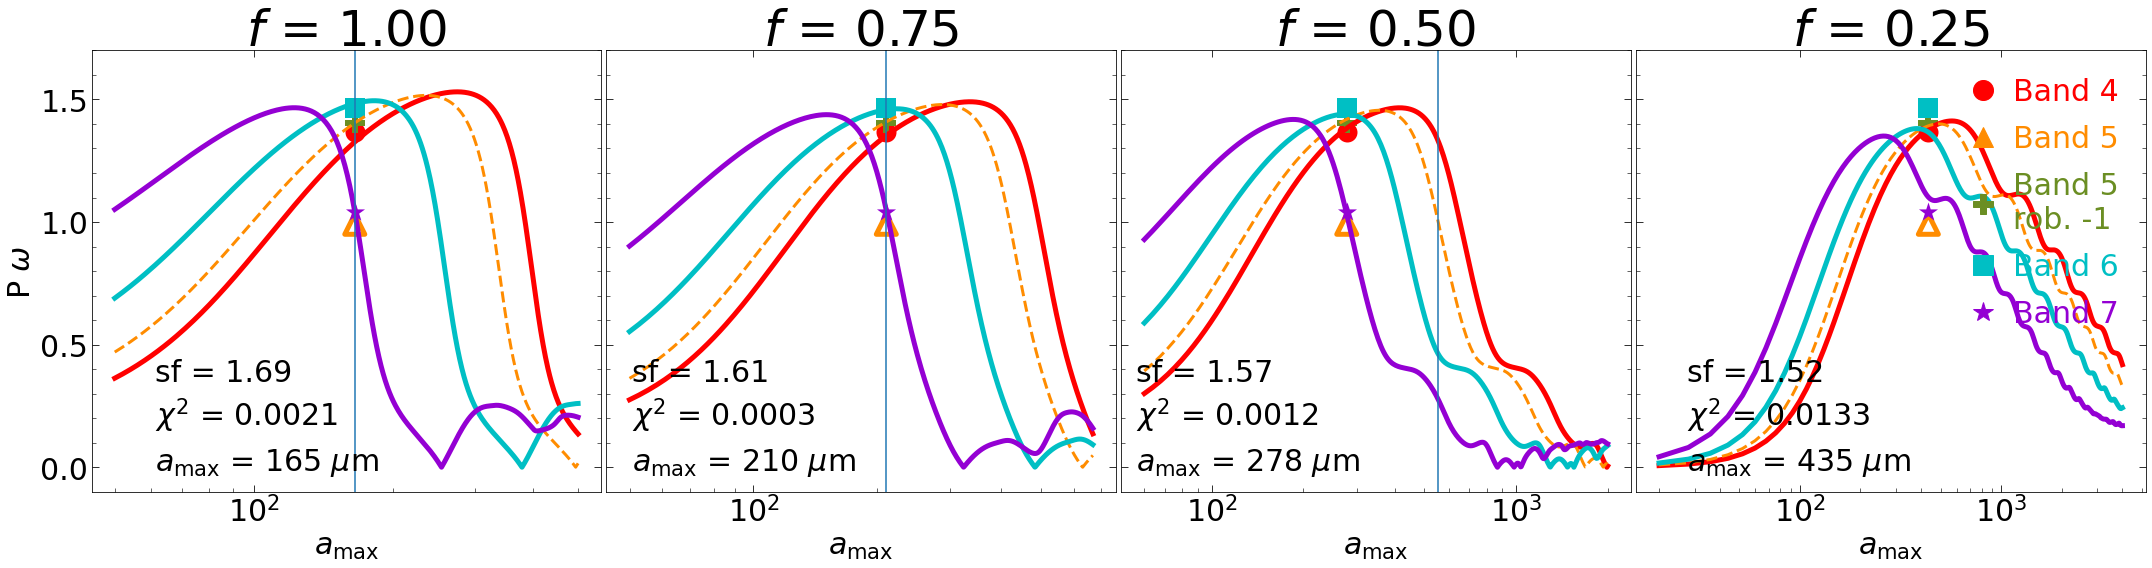

In [29]:
fig, ax = DebuggingPlot('v5',
                        all_bands, 
                        bands_labels, 
                        bands_fit, 
                        f_values,                               
                        a_dist_micron_v5, 
                        P_times_omega_v5,
                        best_sf_v5, 
                        best_idx_arr_v5, 
                        best_a_max_v5, 
                        POLF_obs_for_plot,
                        x_axis = 'a',
                        custom_text_x = [0.075, 0, -0.02, 0.05],
                        chi_sq_precision = 4,
                        )

ax[0].axvline(165)
ax[1].axvline(210)
ax[2].axvline(554)

In [31]:
for f in f_values:

IndentationError: expected an indented block (2568811868.py, line 1)

# v5: but for poster bounds

UnboundLocalError: local variable 'chi_sq' referenced before assignment

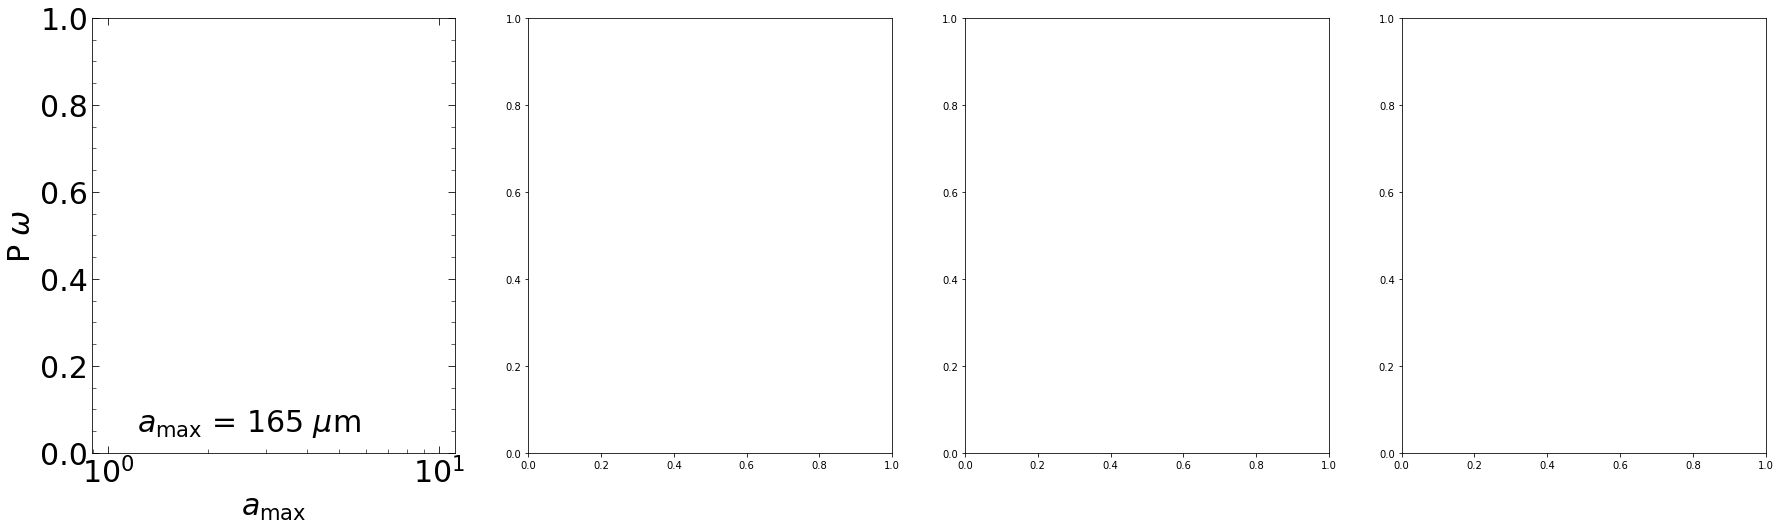

In [30]:
fig, ax = DebuggingPlot('v5',
                        all_bands, 
                        bands_labels, 
                        bands_fit, 
                        f_values,                               
                        a_dist_micron_v5, 
                        P_times_omega_v5,
                        best_sf_v5, 
                        best_idx_arr_v5, 
                        best_a_max_v5, 
                        POLF_obs_for_plot,
                        x_axis = 'a',
                        custom_text_x = [0.075, 0, -0.02, 0.05],
                        chi_sq_precision = 4,
                        for_poster = True)

ax[0].axvline(165)
ax[1].axvline(210)
ax[2].axvline(554)